##José Alberto Isidoro Sánchez

# **FINAL PROJECT PT 3.- KERAS TUNER OPTIMIZATION**

# FASHION MNIST DATASET: GRID SEARCH VS KERAS TUNNER | FINAL PROJECT



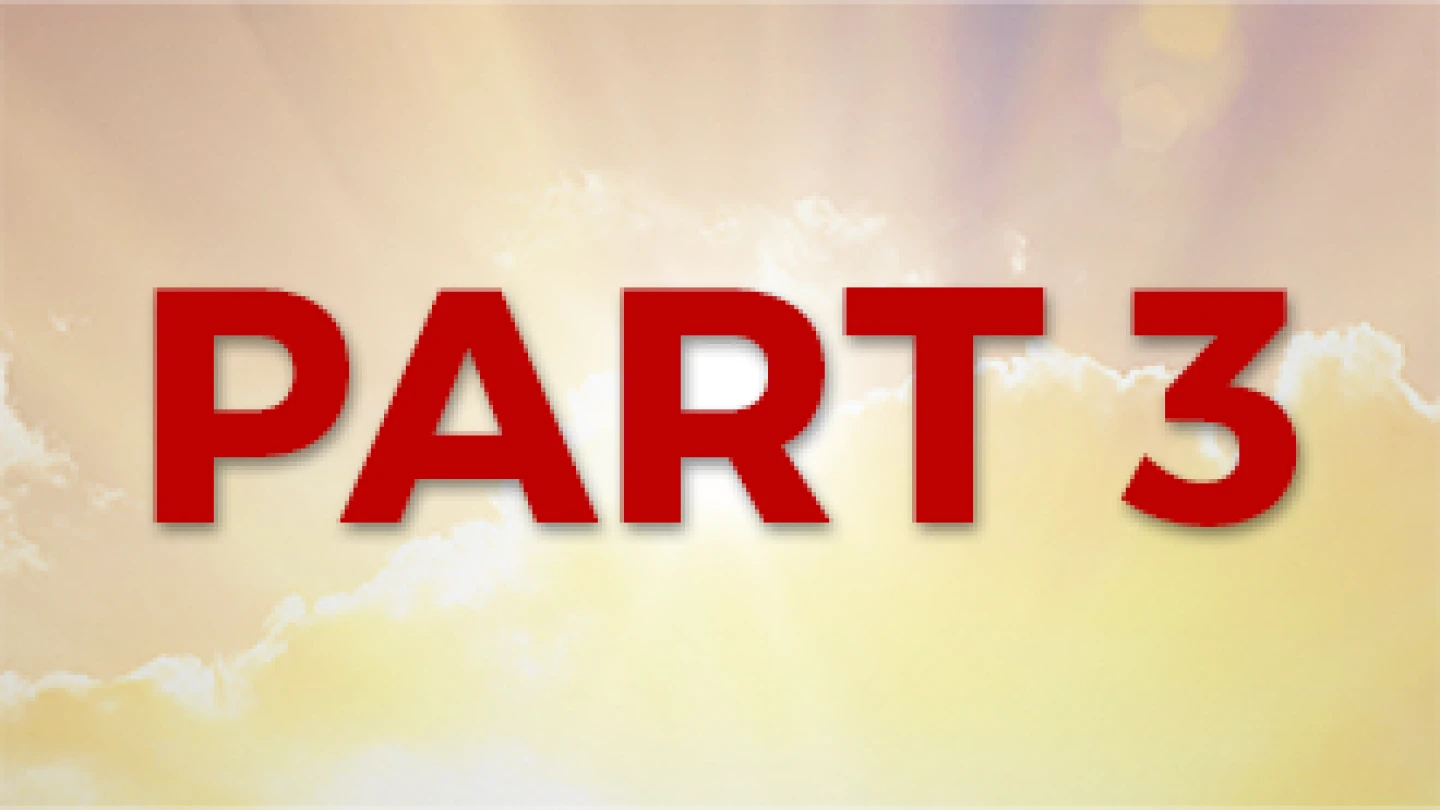

"""
MODEL ARCHITECTURE & HYPERPARAMETER SEARCH SPACE SUMMARY:
---------------------------------------------------------
1. INPUT LAYER:
   - 28x28x1 Grayscale Image (Fashion MNIST)

2. CONVOLUTIONAL BASE (Searchable Architecture):
   - 'Simple_3x3': Standard Conv2D (32 filters, 3x3 kernel, ReLU)
   - 'Optimized_1x1': Dimensionality reduction via 1x1 Conv (16 filters)
      followed by 3x3 Conv (32 filters). Inspired by Inception/ResNet bottlenecks.

3. POOLING & FLATTEN:
   - MaxPooling2D (2x2) for spatial reduction.
   - Flatten layer to transition to Dense layers.

4. DENSE LAYERS (Searchable Parameters):
   - Hidden Layer: Tunable units [64, 128].
   - Regularization: Dropout layer with tunable rate [0.3, 0.5].
   - Output Layer: 10 neurons (Logits) for multi-class classification.

5. OPTIMIZATION STRATEGY (Searchable Schedules):
   - Initial Learning Rates: [0.01, 0.001].
   - Decay Schedules:
      - ExponentialDecay (0.9 rate every 1000 steps).
      - CosineDecay (Smooth drop over 1000 steps).
   - Optimizers: [Adam, SGD, RMSprop].

6. TRAINING CONFIGURATION:
   - Tunable Batch Size: [32, 64].
   - Loss Function: Sparse Categorical Crossentropy (from_logits=True).
"""

# PART 3
# A) KERAS TUNNER

In [ ]:
!pip install keras-tuner -q
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 508.0 kB/s eta 0:00:00


In [ ]:
##=====================
##SETTING UP LIBRARIES
#=====================

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt #install above
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorboard.plugins.hparams import api as hp
import numpy as np
import time
import os
import shutil



In [ ]:

# ============================================
# DATA PREPARATION FUNCTION (CNN VERSION)
# ============================================
def load_and_preprocess_fashion_mnist_cnn(use_subset=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    X_train_orig, X_test_orig = X_train.copy(), X_test.copy()

    if use_subset:
        n_train = int(X_train.shape[0] * 0.2)
        indices = np.random.choice(X_train.shape[0], n_train, replace=False)
        X_train, y_train = X_train[indices], y_train[indices]

    # Normalization & Reshape for CNN
    X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    print("DATA LOADED, ALL GOOD")

    return X_train, y_train, X_test, y_test, X_train_orig, X_test_orig

In [ ]:
#MODEL ARCHITECTURE & HYPERPARAMETER SEARCH SPACE SUMMARY

##MODEL WITH LR scheduler
def build_model(hp):
    model = keras.Sequential()


    # input layer
    model.add(layers.Input(shape=(28, 28, 1)))

    #ARQUITECTURE
    arch_type = hp.Choice('architecture', ['Optimized_1x1', 'Simple_3x3'])
    if arch_type == 'Optimized_1x1':
        model.add(layers.Conv2D(16, (1, 1), activation='relu'))
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    else:
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))

    ###
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())

    # number of neurons
    units = hp.Int('units', 64, 128, step=64) ###step is how many sums and trials?
    model.add(layers.Dense(units, activation='relu'))



    # dropout (regularization)
    #dropout = hp.Choice('dropout', [0.3, 0.5]) # is it equal to this (?): HP_DROPOUT = hp.HParam('dropout', hp.Discrete([0.3, 0.5])))

    model.add(layers.Dropout(hp.Choice('dropout', [0.3, 0.5])))
    model.add(layers.Dense(10))  # No activation here because we use from_logits=True



    ############################################################
    # Learning Rate and Schedule Search
    initial_lr = hp.Choice('learning_rate', [1e-2, 1e-3])
    decay_type = hp.Choice('decay_schedule', ['exponential', 'cosine'])

    if decay_type == 'exponential':
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=initial_lr, decay_steps=1000, decay_rate=0.9)
    else:
        lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=initial_lr, decay_steps=1000)

    # Optimizer Search
    opt_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    if opt_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    elif opt_name == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr_schedule)




    ############################################################
    # Define batch_size as a tunable hyperparameter inside the function
    hp.Choice('batch_size', [32, 64])

    model.summary()

    #COMPILE
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
      )

    return model

"""
MODEL ARCHITECTURE & HYPERPARAMETER SEARCH SPACE SUMMARY:
---------------------------------------------------------
1. INPUT LAYER:
   - 28x28x1 Grayscale Image (Fashion MNIST)

2. CONVOLUTIONAL BASE (Searchable Architecture):
   - 'Simple_3x3': Standard Conv2D (32 filters, 3x3 kernel, ReLU)
   - 'Optimized_1x1': Dimensionality reduction via 1x1 Conv (16 filters)
      followed by 3x3 Conv (32 filters). Inspired by Inception/ResNet bottlenecks.

3. POOLING & FLATTEN:
   - MaxPooling2D (2x2) for spatial reduction.
   - Flatten layer to transition to Dense layers.

4. DENSE LAYERS (Searchable Parameters):
   - Hidden Layer: Tunable units [64, 128].
   - Regularization: Dropout layer with tunable rate [0.3, 0.5].
   - Output Layer: 10 neurons (Logits) for multi-class classification.

5. OPTIMIZATION STRATEGY (Searchable Schedules):
   - Initial Learning Rates: [0.01, 0.001].
   - Decay Schedules:
      - ExponentialDecay (0.9 rate every 1000 steps).
      - CosineDecay (Smooth drop over 1000 steps).
   - Optimizers: [Adam, SGD, RMSprop].

6. TRAINING CONFIGURATION:
   - Tunable Batch Size: [32, 64].
   - Loss Function: Sparse Categorical Crossentropy (from_logits=True).
"""

"\nMODEL ARCHITECTURE & HYPERPARAMETER SEARCH SPACE SUMMARY:\n---------------------------------------------------------\n1. INPUT LAYER:\n   - 28x28x1 Grayscale Image (Fashion MNIST)\n\n2. CONVOLUTIONAL BASE (Searchable Architecture):\n   - 'Simple_3x3': Standard Conv2D (32 filters, 3x3 kernel, ReLU)\n   - 'Optimized_1x1': Dimensionality reduction via 1x1 Conv (16 filters)\n      followed by 3x3 Conv (32 filters). Inspired by Inception/ResNet bottlenecks.\n\n3. POOLING & FLATTEN:\n   - MaxPooling2D (2x2) for spatial reduction.\n   - Flatten layer to transition to Dense layers.\n\n4. DENSE LAYERS (Searchable Parameters):\n   - Hidden Layer: Tunable units [64, 128].\n   - Regularization: Dropout layer with tunable rate [0.3, 0.5].\n   - Output Layer: 10 neurons (Logits) for multi-class classification.\n\n5. OPTIMIZATION STRATEGY (Searchable Schedules):\n   - Initial Learning Rates: [0.01, 0.001].\n   - Decay Schedules:\n      - ExponentialDecay (0.9 rate every 1000 steps).\n      - Cosin

In [ ]:
#--------------------------------------------
# CALL DATA
#------------------------------------------


X_train, y_train, X_test, y_test, X_orig, X_test_orig = load_and_preprocess_fashion_mnist_cnn() #We can erase "use_subset=True" to use full dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
DATA LOADED, ALL GOOD


In [ ]:
# ======================
# Setting directory up
# ================
"""
                        import shutil
                        import os

                        # Clean up previous local runs to save space
                        for folder in ['/content/tuner_results', '/content/logs']:
                            if os.path.exists(folder):
                                shutil.rmtree(folder)
                                print(f"Deleted {folder} to save space.")

"""
import datetime

# 1. Unique ID for TensorBoard session
run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# 2. Define Local Paths (These will be deleted when you close Colab)
tuner_dir = '/content/tuner_results'
log_dir = f'/content/logs/{run_id}'


# ======================
# Define the Tuner
# ======================

# 3. Define the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory=tuner_dir,
    project_name='fashion_mnist_temp_pt3'
)




# ======================
# Tensorboard Callback with dynamic path
# ======================
# This creates a subfolder for THIS specific search session
#log_dir = os.path.join('logs', 'fashion_mnist', run_id)
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351,498 (1.34 MB)

 Trainable params: 351,498 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#-----------------
# 4. Run Search
##---------------
tuner.search(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    # Note: It's safer to let the fit process handle batch_size
    # unless you are specifically tuning it as a hyperparameter.
    callbacks=[tensorboard_callback],
    verbose=1
)

Trial 10 Complete [00h 02m 59s]
val_accuracy: 0.7368999719619751

Best val_accuracy So Far: 0.892300009727478
Total elapsed time: 00h 26m 29s


In [ ]:
# This gives a detailed report of the top 10 trials
tuner.results_summary()

Results summary
Results in /content/tuner_results/fashion_mnist_temp_pt3
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
architecture: Optimized_1x1
units: 128
dropout: 0.3
learning_rate: 0.001
decay_schedule: exponential
optimizer: rmsprop
batch_size: 32
Score: 0.892300009727478

Trial 04 summary
Hyperparameters:
architecture: Simple_3x3
units: 64
dropout: 0.3
learning_rate: 0.01
decay_schedule: cosine
optimizer: adam
batch_size: 64
Score: 0.8751999735832214

Trial 03 summary
Hyperparameters:
architecture: Optimized_1x1
units: 128
dropout: 0.3
learning_rate: 0.01
decay_schedule: exponential
optimizer: adam
batch_size: 32
Score: 0.8733999729156494

Trial 06 summary
Hyperparameters:
architecture: Optimized_1x1
units: 128
dropout: 0.5
learning_rate: 0.01
decay_schedule: cosine
optimizer: adam
batch_size: 64
Score: 0.8718000054359436

Trial 08 summary
Hyperparameters:
architecture: Optimized_1x1
units: 128
dropout: 0.5
learning_rat

## EXPECTED RESULTS (DIFFERENT RUN NUMBERS):


In [ ]:
# 1. Kill any existing TensorBoard instances to prevent port conflicts
!kill $(pgrep tensorboard)

# 2. Reload the extension to ensure it's fresh
%reload_ext tensorboard

# 3. Launch TensorBoard pointing to the base logs directory
%tensorboard --logdir /content/logs/

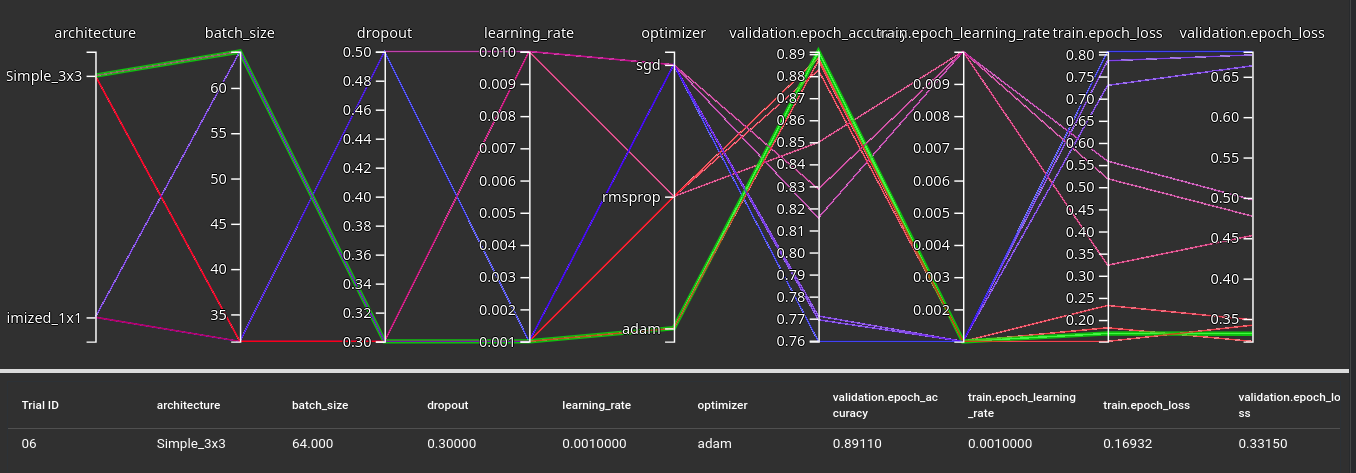

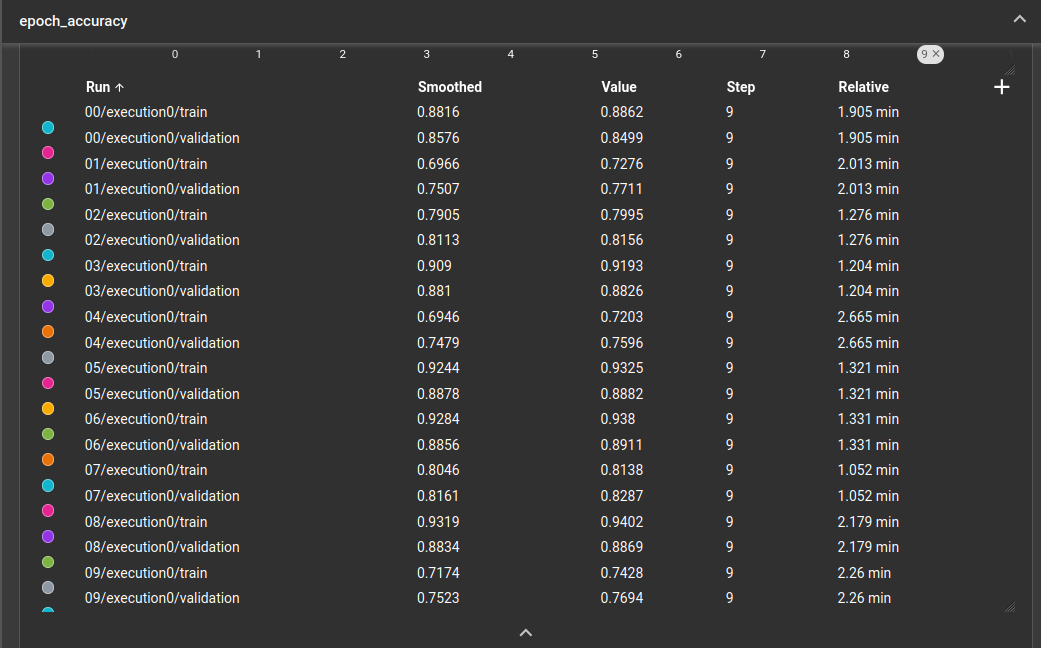

## Extract 2 best models:

In [ ]:
"""
# Get the top 2 models based on the tuner results
best_hparams = tuner.get_best_hyperparameters(num_trials=2)
model1 = tuner.hypermodel.build(best_hparams[0])
model2 = tuner.hypermodel.build(best_hparams[1])

# Re-train them to get the full history object
history1 = model1.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=0)
history2 = model2.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=0)
"""

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,314 (2.66 MB)

 Trainable params: 698,314 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Get the top 3 models based on tuner results
best_hparams = tuner.get_best_hyperparameters(num_trials=3)

# Build and Re-train Top 3 Models
top_models = []
histories = []

for i, hparams in enumerate(best_hparams):
    # This proves which specific Trial from your search is being re-built
    print(f"\n--- Re-training Rank {i+1} (Trial Config: {hparams.values}) ---")

    # 1. Build model from best hyperparameters
    model = tuner.hypermodel.build(hparams)

    # 2. Extract specific batch size used in that trial
    bs = hparams.get('batch_size')

    # 3. Train for more epochs (20 instead of 10) to get full history
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=bs,
        validation_data=(X_test, y_test),
        verbose=1
    )

    top_models.append(model)
    histories.append(history)


--- Re-training Rank 1 (Trial Config: {'architecture': 'Optimized_1x1', 'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'decay_schedule': 'exponential', 'optimizer': 'rmsprop', 'batch_size': 32}) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,314 (2.66 MB)

 Trainable params: 698,314 (2.66 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,314 (2.66 MB)

 Trainable params: 698,314 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.7887 - loss: 0.5995 - val_accuracy: 0.8413 - val_loss: 0.4443
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8531 - loss: 0.4164 - val_accuracy: 0.8428 - val_loss: 0.4314
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8706 - loss: 0.3443 - val_accuracy: 0.8406 - val_loss: 0.4180
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8810 - loss: 0.3115 - val_accuracy: 0.8662 - val_loss: 0.3891
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.8988 - loss: 0.2702 - val_accuracy: 0.8570 - val_loss: 0.4602
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9054 - loss: 0.2465 - val_accuracy: 0.8660 - val_loss: 0.4485
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9156 - loss: 0.2282 - val_accuracy: 0.8612 - val_loss: 0.4525
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9248 - loss: 0.2017 - 

In [ ]:
"""

def visualize_model_predictions(model, title, num_images=10):
    predictions = model.predict(X_test[:num_images])
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        pred_label = np.argmax(predictions[i])
        true_label = y_test[i]
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"P: {class_names[pred_label]}\n(T: {class_names[true_label]})",
                  color=color, fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Sample Predictions: {title}", fontsize=16)
    plt.show()

# Run visualization for your Top 3
for i in range(3):
    visualize_model_predictions(top_models[i], f"Rank {i+1} Model")
    plot_performance(histories[i], f"Rank {i+1} Performance") # Uses your existing plot function [cite: 392]

"""

In [ ]:
def plot_performance(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

def visualize_model_predictions(model, title, num_images=10):
    predictions = model.predict(X_test[:num_images])
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        pred_label = np.argmax(predictions[i])
        true_label = y_test[i]
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"P: {class_names[pred_label]}\n(T: {class_names[true_label]})",
                  color=color, fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Sample Predictions: {title}", fontsize=16)
    plt.show()


RESULTS FOR RANK 1 MODEL


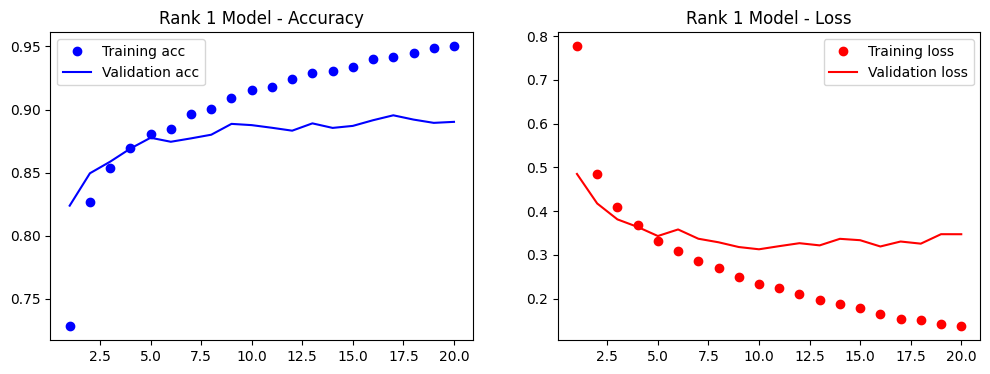

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


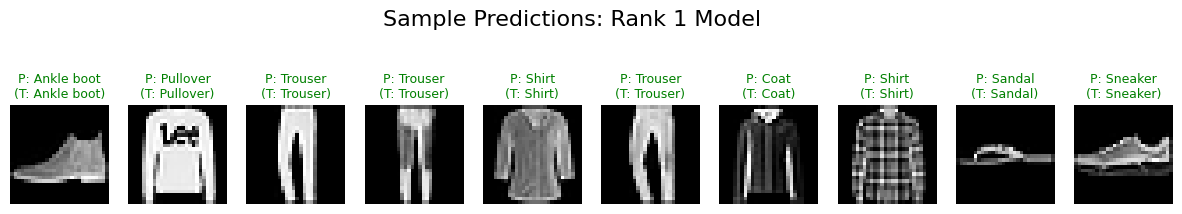


RESULTS FOR RANK 2 MODEL


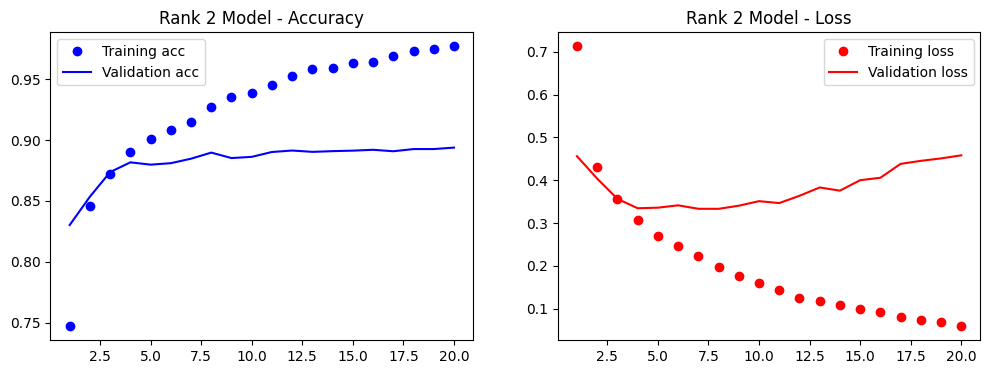

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


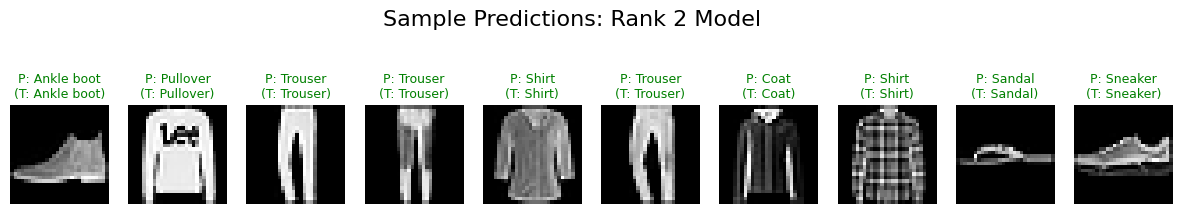


RESULTS FOR RANK 3 MODEL


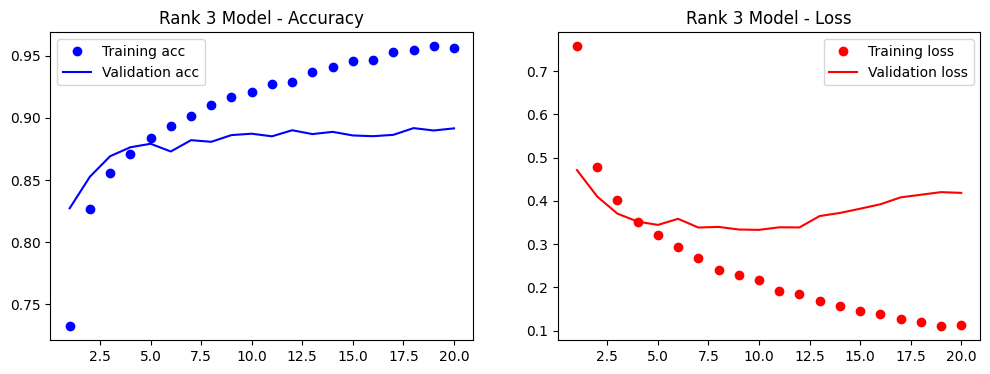

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


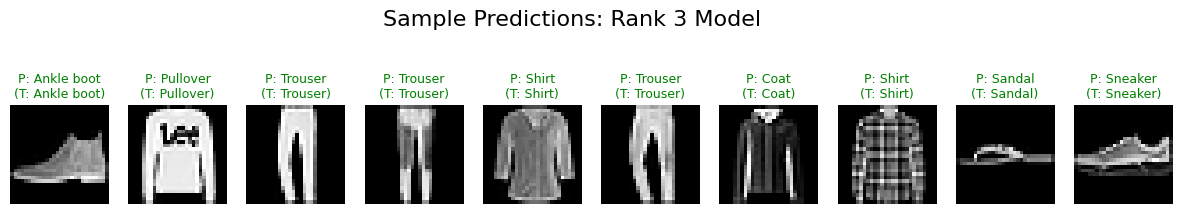

In [ ]:
# 3. Final Comparison Visualization
# This loop handles all 3 models automatically using your lists
for i in range(3):
    print(f"\n{'='*30}")
    print(f"RESULTS FOR RANK {i+1} MODEL")
    print(f"{'='*30}")

    # This plots the Training vs Validation curves
    plot_performance(histories[i], f"Rank {i+1} Model")

    # This shows the actual images and labels
    visualize_model_predictions(top_models[i], f"Rank {i+1} Model")



---

---



---



---



---



---





---



---



---



---



---



---



---



---



---



# Old code used to craft this model

In [ ]:
"""
##MODEL without LR scheduler
def build_model(hp):
    model = keras.Sequential()


    # input layer
    model.add(layers.Input(shape=(28, 28, 1)))

    #ARQUITECTURE
    arch_type = hp.Choice('architecture', ['Optimized_1x1', 'Simple_3x3'])
    if arch_type == 'Optimized_1x1':
        model.add(layers.Conv2D(16, (1, 1), activation='relu'))
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    else:
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))

    ###
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())

    # number of neurons
    units = hp.Int('units', 64, 128, step=64) ###step is how many sums and trials?
    model.add(layers.Dense(units, activation='relu'))



    # dropout (regularization)
    #dropout = hp.Choice('dropout', [0.3, 0.5]) # is it equal to this (?): HP_DROPOUT = hp.HParam('dropout', hp.Discrete([0.3, 0.5])))

    model.add(layers.Dropout(hp.Choice('dropout', [0.3, 0.5])))
    model.add(layers.Dense(10))  # No activation here because we use from_logits=True



    # learning rate

    lr = hp.Choice('learning_rate', [0.001, 0.01])

    # optimizer choice


    optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])

    if optimizer_name == 'adam':
       optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
       optimizer = keras.optimizers.SGD(learning_rate=lr)
    elif optimizer_name == 'rmsprop':
       optimizer = keras.optimizers.RMSprop(learning_rate=lr)

    else:
       print("Invalid optimizer name")
       return

    # Define batch_size as a tunable hyperparameter inside the function
    hp.Choice('batch_size', [32, 64])

    model.summary()

    #COMPILE
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
      )

    return model

FROM GRID SEARCH, this are my old parameters, I want to imitate this for kears tunner

                            HP_ARCH = hp.HParam('architecture', hp.Discrete(['Simple_3x3', 'Optimized_1x1']))
                            HP_NUM_UNITS = hp.HParam('num_units', hp.Discrete([64, 128]))
                            HP_DROPOUT = hp.HParam('dropout', hp.Discrete([0.3, 0.5]))
                            HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'sgd', 'rmsprop']))
                            HP_BATCH = hp.HParam('batch_size', hp.Discrete([32, 64]))

                            # Architecture Logic
                              if hparams[HP_ARCH] == 'Optimized_1x1':
                                  # Chain: 1x1 THEN 3x3
                                  model.add(layers.Conv2D(16, (1, 1), activation='relu'))
                                  model.add(layers.Conv2D(32, (3, 3), activation='relu'))
                              else:
                                  # Just 3x3
                                  model.add(layers.Conv2D(32, (3, 3), activation='relu'))

                              model.add(layers.MaxPooling2D((2, 2)))
                              model.add(layers.Flatten())
                              model.add(layers.Dense(hparams[HP_NUM_UNITS], activation='relu'))
                              model.add(layers.Dropout(hparams[HP_DROPOUT]))
                              model.add(layers.Dense(10))

                              model.compile(
                                  optimizer=hparams[HP_OPTIMIZER],
                                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                                  metrics=['accuracy'],
                              )

                              # Capture history to get losses
                              history = model.fit(
                                  X_train, y_train,
                                  epochs=5,
                                  batch_size=hparams[HP_BATCH],
                                  validation_split=0.1,
                                  verbose=0,
                                  callbacks=[
                                      tf.keras.callbacks.TensorBoard(run_log_dir),
                                      hp.KerasCallback(run_log_dir, hparams),
                                  ],
                              )
"""
